# Minimal total field in the scattered-voltage basis $V_\mathrm{sca}$

Same setting as `VscatBound.ipynb` and `maxMatDens.ipynb` (global and GCD local power conservation constraints, optimization variable
$V_\mathrm{sca} = -Z_0 I$, $I = -W V_\mathrm{sca}$, $W = Z_0^{-1}$), with the objective replaced by the total-field intensity
$$\min \|d\|^2 = \sum_i |d_i|^2, \qquad d_i = \left(V - Z_0 I\right)_i = \left(V + V_\mathrm{sca}\right)_i ,$$
the $\|d\|^2$ term of `maxMatDens.ipynb` alone. It is solved as the maximization of $f = -\|d\|^2$, so the dual value $D$ gives the
lower bound $\|d\|^2 \geq -D$ over all structures. For the full plate $d = Z_s I$, while the empty design region has $d = V$.

In [1]:
import numpy as np
import scipy.sparse as sp
import time
from dolphindes.cvxopt import DenseSharedProjQCQP, OptimizationHyperparameters

In [2]:
# Physical constants
epsilon_0 = 8.854e-12 # F/m
mu_0 = 4e-7 * np.pi # H/m
c = 1/np.sqrt(epsilon_0 * mu_0) # speed of light in vacuum

E0 = 1e3 # plane wave amplitude in V/m

frequency = 2.45e9 # frequency in Hz
wavelength = c / frequency # wavelength in m
print(f"Wavelength: {wavelength} m")

ka = 1 # electrical size of the antenna
k = 2 * np.pi / wavelength # wavenumber
a = ka / k # antenna circumradius
print(f"Antenna circumradius: {a} m")

omega = 2 * np.pi * frequency # angular frequency

conductivity_reduction_factor = 1 # factor to reduce conductivity for testing purposes
copper_conductivity = conductivity_reduction_factor*5.96e7 # S/m
copper_permittivity = 1 + 1j * copper_conductivity / (omega * epsilon_0) # copper permittivity in dimensionless units
print(f"Copper permittivity: {copper_permittivity:.2e}")

Wavelength: 0.1223655664053944 m
Antenna circumradius: 0.019475084757658086 m
Copper permittivity: 1.00e+00+4.37e+08j


In [3]:
# Calculate surface impedance
delta = np.sqrt(2 / (omega * mu_0 * copper_conductivity)) # skin depth in m
Zs = (1 + 1j) / (copper_conductivity * delta)
print(f"Surface impedance: {Zs} Ω")

# Load matrices from text files
Lmat = np.loadtxt(r"Lmat_dipole.txt", delimiter=',') # lossy matrix

Ndes = Lmat.shape[0] # number of design variables
print("Number of design variables: ", Ndes)

Lchol = np.linalg.cholesky(Lmat).conj().T
LcholInv = np.linalg.inv(Lchol)

def Msym(M):
    return(0.5*(M.conj().T + M))

def Mchol(M):
    return(Msym(LcholInv.conj().T @ M @ LcholInv))

R0 = np.loadtxt(r"R0_dipole.txt", delimiter=',') # radiated power matrix
R0 = Mchol(R0)

X0 = np.loadtxt(r"X0_dipole.txt", delimiter=',') # reactive power matrix
X0 = Mchol(X0)

Vinc = np.loadtxt(r"V_dipole.txt", delimiter=',') # voltage excitation vector
Vinc = E0*Vinc
def Vchol(v):
    return(LcholInv.conj().T @ v)
Vinc = Vchol(Vinc)

Zmat = Zs * np.eye(Ndes) # material impedance matrix
Z0 = R0 + 1j*X0 # free-space impedance matrix
Ztot = Z0 + Zmat # total impedance matrix

def evalObjI(Ivec):
    # total-field intensity ||d||^2, d = V - Z0 I (current basis)
    return(np.linalg.norm(Vinc - Z0 @ Ivec)**2)

# full plate performance
Ifull = np.linalg.solve(Ztot, Vinc) # current distribution for full plate
Pfull = evalObjI(Ifull) # objective for full plate
print(f"||d||^2: full plate {Pfull:.6e} V^2, empty design region ||V||^2 = {np.linalg.norm(Vinc)**2:.6e} V^2")

Surface impedance: (0.012739130327240646+0.012739130327240646j) Ω
Number of design variables:  195
||d||^2: full plate 5.511968e-03 V^2, empty design region ||V||^2 = 2.929336e+01 V^2


## Objective in $V_\mathrm{sca}$

With $d = V + x$, $x = V_\mathrm{sca}$, $\|d\|^2 = x^H x + 2\operatorname{Re}(x^H V) + \|V\|^2$, so $f = -\|d\|^2$ is the dolphindes form
$-x^H A_0 x + 2\operatorname{Re}(x^H s_0) + c_0$ with
$$A_0 = \mathbf 1,\qquad s_0 = -V,\qquad c_0 = -\|V\|^2 .$$
Without constraints the minimum is $\|d\|^2 = 0$ at $x = -V$, i.e. $I = WV$, which violates the real power conservation
($\operatorname{Re}[I^H(V + V_\mathrm{sca} - Z_s I)] = -R_s\|I\|^2 \neq 0$).

In [4]:
print(f"cond(Z0) = {np.linalg.cond(Z0):.3e}")
W = np.linalg.inv(Z0)   # Z0^{-1}
WH = W.conj().T

Obj = np.eye(Ndes, dtype=complex)
obj = -Vinc.astype(complex)
obj0 = -np.linalg.norm(Vinc)**2

def VtoI(Vsca):
    return(-W @ Vsca)

def evalObj(Vsca):
    # f = -||d||^2 in the dolphindes form
    return(-np.real(Vsca.conj().T @ Obj @ Vsca) + 2*np.real(Vsca.conj().T @ obj) + obj0)

def fieldNorm2(Vsca):
    # ||d||^2 evaluated directly, d = V + Vsca
    return(np.linalg.norm(Vinc + Vsca)**2)

def fieldWeightedDensity(Vsca):
    # Re[d^H a] / ||d||^2, a = Zs I, the field-weighted fill fraction p
    return(np.real(np.vdot(Vinc + Vsca, Zs*VtoI(Vsca)))/fieldNorm2(Vsca))

Vfull = -Z0 @ Ifull # scattered voltage for full plate
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
print(f"random x: -quadratic form {-evalObj(xRand):.6e}, direct {fieldNorm2(xRand):.6e}")
print(f"||d||^2 for full plate in Vsca: {fieldNorm2(Vfull):.6e} V^2 (I basis {Pfull:.6e} V^2), "
      f"field-weighted density {fieldWeightedDensity(Vfull):.6f}")

cond(Z0) = 1.750e+04
random x: -quadratic form 3.981378e+02, direct 3.981378e+02
||d||^2 for full plate in Vsca: 5.511968e-03 V^2 (I basis 5.511968e-03 V^2), field-weighted density 1.000000


## Power conservation in the shared projector form

For a complex diagonal projector $P = \operatorname{diag}(p)$ the constraint $\operatorname{Re}\left[I^H P (V + V_\mathrm{sca} - Z_s I)\right] = 0$
holds for any structure. With $I = -W V_\mathrm{sca}$ it reads $\operatorname{Re}\left(-x^H B x + 2x^H s\right) = 0$,
$$B = W^H P (1 + Z_s W),\qquad s = -\tfrac12 W^H P V ,$$
without a constant. Using $\operatorname{Re}(x^H B x) = \operatorname{Re}(x^H B^H x)$, $B^H = (1 + Z_s^* W^H)\, P^*\, W$, this is the shared projector form
$\operatorname{Re}\left(-x^H A_1 P' A_2 x + 2 x^H A_2^H P'^H s_1\right) = 0$ with
$$A_1 = 1 + Z_s^* W^H,\qquad A_2 = W,\qquad s_1 = -\tfrac12 V,\qquad P' = P^H = \operatorname{diag}(p^*),$$
i.e. the current-basis constraint with $U^H = A_1$ and $I = -A_2 x$ written in $V_\mathrm{sca}$.

The global real ($p = \mathbf 1$) and reactive ($p = -j\mathbf 1$) power constraints are $P' = \mathbf 1$ and $P' = j\mathbf 1$.
For $P' = \mathbf 1$, $\operatorname{Sym}(A_1 A_2) = W^H \operatorname{Re}(Z_\mathrm{tot}) W$ (using $\operatorname{Sym}W = W^H R_0 W$),
the congruent image of the $I$-basis real power constraint.

In [5]:
A1 = np.eye(Ndes) + np.conj(Zs) * WH
A2 = W
s1 = -0.5 * Vinc

qList = [1, -1j]   # real and imaginary part (real and reactive power), p = q 1
Plist = [sp.diags(np.conj(q)*np.ones(Ndes, dtype=complex)) for q in qList]   # P' = diag(p^*)

def projRes(x, Pp):
    # Re(-x^H A1 P' A2 x + 2 x^H A2^H P'^H s1)
    return(np.real(-x.conj() @ A1 @ (Pp @ (A2 @ x)) + 2*x.conj() @ (A2.conj().T @ (Pp.conj().T @ s1))))

def directRes(Vsca, p):
    # Re[I^H diag(p) (V + Vsca - Zs I)] evaluated directly
    I = VtoI(Vsca)
    return(np.real(np.sum(p*np.conj(I)*(Vinc + Vsca - Zs*I))))

print("power conservation residuals at full plate:",
      [f"{projRes(Vfull, Pp):.2e} (direct {directRes(Vfull, q*np.ones(Ndes)):.2e})" for Pp, q in zip(Plist, qList)])

# check: shared projector form equals the direct constraint for a random projector at a random point
pRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
xRand = np.random.randn(Ndes) + 1j*np.random.randn(Ndes)
print(f"random p, random x: shared form {projRes(xRand, sp.diags(np.conj(pRand))):.6e}, direct {directRes(xRand, pRand):.6e}")

power conservation residuals at full plate: ['-3.38e-13 (direct -3.44e-13)', '2.26e-12 (direct 2.26e-12)']
random p, random x: shared form -3.333168e-01, direct -3.333168e-01


## Dual problem

With the real ($P' = \mathbf 1$) and reactive ($P' = j\mathbf 1$) power multipliers $\lambda$, $\mu$,
$$A(\lambda,\mu) = \mathbf 1 + W^H\left[\lambda (R_0 + R_s) + \mu (X_0 + X_s)\right] W ,$$
so $\lambda = \mu = 0$ is dual feasible ($A = \mathbf 1$), giving the trivial bound $\|d\|^2 \geq 0$ as the starting point.

In [6]:
QCQP = DenseSharedProjQCQP(Obj, obj, obj0, A1, s1, Plist, A2=A2, verbose=1)

lags_init = np.zeros(2)   # A = 1
print(f"initial lags dual feasible: {QCQP.is_dual_feasible(lags_init)}")

opt_params = OptimizationHyperparameters(opttol=1e-6,
    gradConverge=True,
    min_inner_iter=10,
    max_restart=10,
    penalty_ratio=1e-2,
    penalty_reduction=0.1,
    break_iter_period=5,
    verbose=0)

t1 = time.time()
result = QCQP.solve_current_dual_problem(method='newton', init_lags=lags_init, opt_params=opt_params)
print(f"lower bound on ||d||^2: {-result[0]:.6e} V^2, time: {time.time()-t1:.2f}s, Lagrange multipliers: {QCQP.current_lags}")

Precomputed 2 A matrices and Fs vectors.
initial lags dual feasible: True
lower bound on ||d||^2: 5.511968e-03 V^2, time: 0.07s, Lagrange multipliers: [0.02493903 0.02549229]


In [7]:
lags = QCQP.current_lags
totalA = QCQP._get_total_A(lags)
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(totalA))):.3e}")

Vstar = QCQP.current_xstar
Istar = VtoI(Vstar)
print(f"lower bound {-QCQP.current_dual:.6e} V^2, ||d||^2(x*) {fieldNorm2(Vstar):.6e} V^2 (I basis {evalObjI(Istar):.6e} V^2), "
      f"full plate {Pfull:.6e} V^2, relative gap {(Pfull + QCQP.current_dual)/Pfull:.2e}")
print(f"field-weighted density at x*: {fieldWeightedDensity(Vstar):.6f}, "
      f"||I* - I_full|| / ||I_full|| = {np.linalg.norm(Istar - Ifull)/np.linalg.norm(Ifull):.2e}")
print("constraint residuals at x*:", [f"{projRes(Vstar, Pp):.2e}" for Pp in Plist])

minimum eigenvalue of A: 9.989e-01
lower bound 5.511968e-03 V^2, ||d||^2(x*) 5.511958e-03 V^2 (I basis 5.511958e-03 V^2), full plate 5.511968e-03 V^2, relative gap 4.57e-09
field-weighted density at x*: 1.000001, ||I* - I_full|| / ||I_full|| = 2.53e-08
constraint residuals at x*: ['-1.43e-07', '-2.73e-07']


## Reference: global bound in the $I$ basis

In the current basis $\|V - Z_0 I\|^2 = I^H Z_0^H Z_0 I - 2\operatorname{Re}(I^H Z_0^H V) + \|V\|^2$, so
$A_0 = Z_0^H Z_0$, $s_0 = Z_0^H V$, $c_0 = -\|V\|^2$, with a condition number $\operatorname{cond}(Z_0)^2$, whereas in the $V_\mathrm{sca}$
basis $A_0 = \mathbf 1$. As in `maxMatDens.ipynb`, the check is done at fixed multipliers: the $I$-basis power constraints are the
$V_\mathrm{sca}$ ones combined by a $2\times 2$ matrix $M$, so the $I$-basis dual at $\lambda_I = M^{-T}\lambda$ must equal the
$V_\mathrm{sca}$ dual up to the round-off of $s^H A^{-1} s \approx \|V\|^2$, which cancels against $c_0$.

In [8]:
Umat = -1j * Ztot.conj()/np.conj(Zs)   # A1 = U^H with U = j Ztot (Ztot symmetric)
eVec = 1j * Vinc / 2/Zs
Pdiags = np.conj(Zs) * np.column_stack([np.ones(Ndes), 1j*np.ones(Ndes)]).astype(complex)  # global: Im and Re part
PlistI = [sp.diags(Pdiags[:, i]) for i in range(Pdiags.shape[1])]

QCQP_I = DenseSharedProjQCQP(Msym(Z0.conj().T @ Z0), Z0.conj().T @ Vinc, -np.linalg.norm(Vinc)**2, Umat, eVec, PlistI, verbose=0)

def projResI(I, P):
    # I-basis constraint Re(-I^H U^H P I + 2 I^H P^H e)
    return(np.real(-I.conj() @ Umat @ (P @ I) + 2*I.conj() @ (P.conj().T @ eVec)))

# I-basis constraints = M @ Vsca-basis constraints, fitted at random points
Xr = [np.random.randn(Ndes) + 1j*np.random.randn(Ndes) for _ in range(6)]
RV = np.array([[projRes(x, Pp) for Pp in Plist] for x in Xr])
RI = np.array([[projResI(VtoI(x), P) for P in PlistI] for x in Xr])
M = np.linalg.lstsq(RV, RI, rcond=None)[0].T
print(f"M = {np.round(M, 12).tolist()}, fit residual {np.linalg.norm(RV @ M.T - RI)/np.linalg.norm(RI):.2e}")

lagsI = np.linalg.solve(M.T, QCQP.current_lags)
dualI = QCQP_I.get_dual(lagsI)[0]
print(f"lower bound on ||d||^2: I basis at mapped multipliers {-dualI:.6e} V^2, Vsca basis {-result[0]:.6e} V^2, "
      f"relative difference {abs(dualI-result[0])/result[0]:.2e}")
print(f"cond(A): Vsca basis {np.linalg.cond(QCQP._get_total_A(QCQP.current_lags)):.3e}, "
      f"I basis {np.linalg.cond(QCQP_I._get_total_A(lagsI)):.3e}")
xI = QCQP_I._get_xstar(lagsI)[0]
print(f"relative difference of x*: {np.linalg.norm(xI - Istar)/np.linalg.norm(xI):.2e}")

M = [[0.0, -1.0], [1.0, 0.0]], fit residual 5.81e-13
lower bound on ||d||^2: I basis at mapped multipliers 5.514727e-03 V^2, Vsca basis 5.511968e-03 V^2, relative difference -5.01e-04
cond(A): Vsca basis 1.022e+00, I basis 3.000e+08
relative difference of x*: 1.12e-07


## Local projector constraints by GCD

Since the local constraints share $A_1$, $A_2$, $s_1$ with the global ones, they are generated directly by
`dolphindes.cvxopt.gcd.run_gcd`. Each GCD iteration adds two diagonal projectors $P' = \operatorname{diag}(p'^*)$:

1. **Strongest local violation:** $p'_i = (2s_1 - A_1^H x^\star)_i (A_2 x^\star)_i^*$, which equals
   $I_i^{\star *}\left(V + V^\star_{\mathrm{sca}} - Z_s I^\star\right)_i$ with $I^\star = -W x^\star$, the pointwise violation
   of the power conservation (zero for any physical structure).
2. **Minimal eigenvalue:** $p'_i = (A_1^H v)_i (A_2 v)_i^*$ for the eigenvector $v$ of $A(\lambda)$ with the smallest eigenvalue,
   normalized elementwise to unit modulus.

The projectors are kept orthonormal in the Hilbert-Schmidt metric of the constraints, and the number of projectors is capped at
`max_proj_cstrt_num`, which is set large enough that no constraints are merged within `max_gcd_iter_num` iterations.

In [9]:
import copy
from dolphindes.cvxopt.gcd import GCDHyperparameters

Ngcd = 20   # number of GCD iterations, each adds a max violation and a min eigenvalue projector

gQCQP = copy.deepcopy(QCQP)
gQCQP.verbose = 0
gcd_params = GCDHyperparameters(max_proj_cstrt_num=2 + 2*Ngcd,
    max_gcd_iter_num=Ngcd,
    gcd_iter_period=Ngcd + 1,   # no early termination
    opt_params=opt_params)

def localViolation(Vsca):
    # pointwise w_i = I_i^* (V + Vsca - Zs I)_i, zero for any physical structure
    I = VtoI(Vsca)
    return(np.conj(I)*(Vinc + Vsca - Zs*I))

t1 = time.time()
gQCQP.run_gcd(gcd_params)
print(f"lower bound on ||d||^2: {-QCQP.current_dual:.6e} -> {-gQCQP.current_dual:.6e} V^2 (full plate {Pfull:.6e} V^2), "
      f"{gQCQP.n_proj_constr} projectors, {time.time()-t1:.2f}s")

At GCD iteration #1, best dual bound found is             -0.0055119681954138855.
min eigenvalue: 9.988961e-01


At GCD iteration #2, best dual bound found is             -0.005511968213536278.
min eigenvalue: 9.988962e-01
At GCD iteration #3, best dual bound found is             -0.005511968217536634.
min eigenvalue: 9.988962e-01


At GCD iteration #4, best dual bound found is             -0.005511968218961272.
min eigenvalue: 9.988962e-01


At GCD iteration #5, best dual bound found is             -0.00551196821960076.
min eigenvalue: 9.988962e-01


At GCD iteration #6, best dual bound found is             -0.005511968219916952.
min eigenvalue: 9.988962e-01


...

At GCD iteration #17, best dual bound found is             -0.00551196822013722.
min eigenvalue: 9.988962e-01


At GCD iteration #18, best dual bound found is             -0.005511968220126562.
min eigenvalue: 9.988962e-01


At GCD iteration #19, best dual bound found is             -0.0055119682201301146.
min eigenvalue: 9.988962e-01


At GCD iteration #20, best dual bound found is             -0.0055119682201301146.
min eigenvalue: 9.988962e-01


At GCD iteration #21, best dual bound found is             -0.0055119682201301146.
lower bound on ||d||^2: 5.511968e-03 -> 5.511968e-03 V^2 (full plate 5.511968e-03 V^2), 42 projectors, 2.37s


minimum eigenvalue of A: 9.989e-01
lower bound 5.511968e-03 V^2, ||d||^2(x*) 5.511968e-03 V^2, field-weighted density at x* 1.000000
max |constraint residual| at x*: 1.16e-11 (global), 6.46e-08 (all)
||local violation||: global 1.307e-06, GCD 5.054e-08


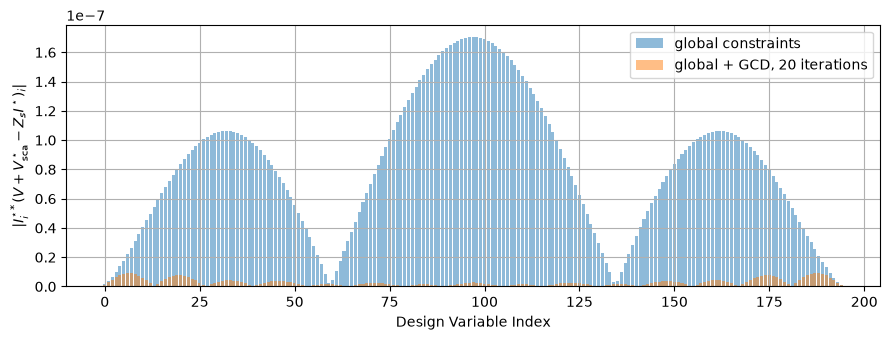

In [10]:
import matplotlib.pyplot as plt

Vstar = gQCQP.current_xstar
print(f"minimum eigenvalue of A: {np.min(np.linalg.eigvalsh(Msym(gQCQP._get_total_A(gQCQP.current_lags)))):.3e}")
print(f"lower bound {-gQCQP.current_dual:.6e} V^2, ||d||^2(x*) {fieldNorm2(Vstar):.6e} V^2, "
      f"field-weighted density at x* {fieldWeightedDensity(Vstar):.6f}")
PlistG = gQCQP.Proj.get_Pdata_column_stack()
print(f"max |constraint residual| at x*: {max(abs(projRes(Vstar, Pp)) for Pp in Plist):.2e} (global), "
      f"{max(abs(projRes(Vstar, sp.diags(PlistG[:, j]))) for j in range(PlistG.shape[1])):.2e} (all)")
print(f"||local violation||: global {np.linalg.norm(localViolation(QCQP.current_xstar)):.3e}, "
      f"GCD {np.linalg.norm(localViolation(Vstar)):.3e}")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(np.arange(Ndes), np.abs(localViolation(QCQP.current_xstar)), alpha=0.5, label='global constraints')
ax.bar(np.arange(Ndes), np.abs(localViolation(Vstar)), alpha=0.5, label=f'global + GCD, {Ngcd} iterations')
ax.set_xlabel('Design Variable Index'); ax.set_ylabel(r'$|I^{\star *}_i(V + V^\star_\mathrm{sca} - Z_s I^\star)_i|$')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

## Inferred complex material density

Material density per basis function (as in `densityConstraintsImag.ipynb`), from the total voltage $V + V_\mathrm{sca}$,
$$\rho_i = \frac{Z_s I_i}{V_i + V_{\mathrm{sca},i}}, \qquad I = -W V_\mathrm{sca},$$
equal to 1 on material and 0 on empty basis functions for a physical structure.

global constraints: Re rho in [1.000, 1.000], Im rho in [-0.000, 0.000], ||Im rho||/||rho|| 1.042e-04
global + GCD, 20 iterations: Re rho in [1.000, 1.000], Im rho in [-0.000, 0.000], ||Im rho||/||rho|| 4.373e-05


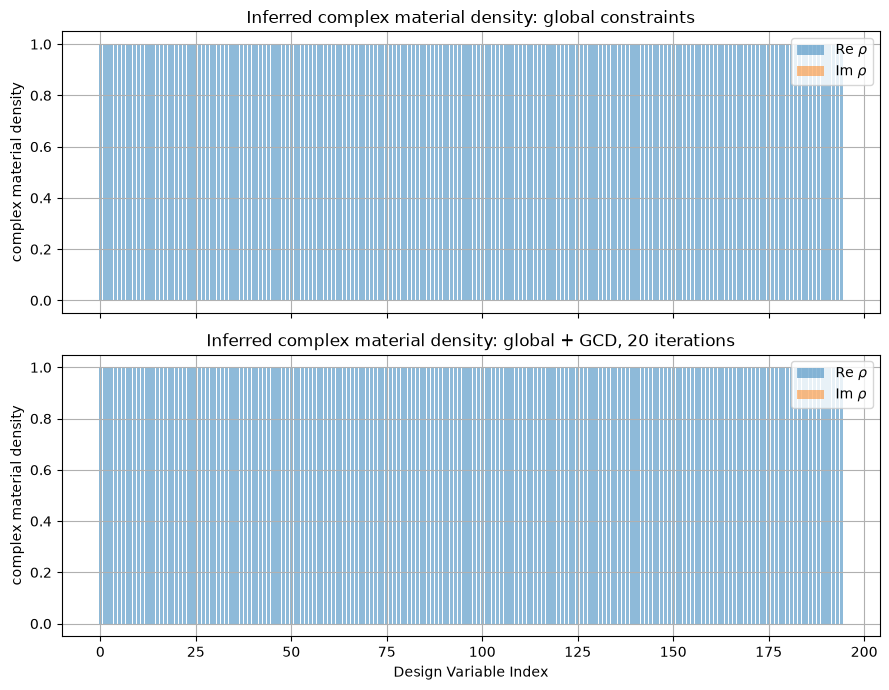

In [11]:
def complexDensity(Vsca):
    # inferred complex material density rho = Zs I / (V + Vsca) (Cholesky space)
    return Zs*VtoI(Vsca)/(Vinc + Vsca)

rhoGlob = complexDensity(QCQP.current_xstar)    # global constraints
rhoLoc = complexDensity(gQCQP.current_xstar)    # after Ngcd GCD iterations
cases = [("global constraints", rhoGlob), (f"global + GCD, {Ngcd} iterations", rhoLoc)]
for name, rho in cases:
    print(f"{name}: Re rho in [{rho.real.min():.3f}, {rho.real.max():.3f}], "
          f"Im rho in [{rho.imag.min():.3f}, {rho.imag.max():.3f}], ||Im rho||/||rho|| {np.linalg.norm(rho.imag)/np.linalg.norm(rho):.3e}")

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, (name, rho) in zip(axes, cases):
    ax.bar(np.arange(Ndes), np.real(rho), alpha=0.5, label=r'Re $\rho$')
    ax.bar(np.arange(Ndes), np.imag(rho), alpha=0.5, label=r'Im $\rho$')
    ax.set_ylabel('complex material density'); ax.set_title(f'Inferred complex material density: {name}')
    ax.legend(); ax.grid(True)
axes[-1].set_xlabel('Design Variable Index')
plt.tight_layout(); plt.show()

## Inference optimization over the material density $\rho$

The ratio above gives a complex $\rho$ with no bounds. A physical structure needs a real $\rho_i \in [0, 1]$ such that the current is that
of the material excited by the total field, $I_i = \rho_i\, Z_s^{-1} E_{\mathrm{tot},i}$ with $E_\mathrm{tot} = V + V_\mathrm{sca}$.
The density is therefore inferred from the fit
$$\min_{\rho\in[0,1]^N} \left\| \operatorname{diag}(\rho)\, Z_s^{-1} E_\mathrm{tot} - I \right\|^2, \qquad I = -W V_\mathrm{sca},$$
which separates over the basis functions. With $b_i = E_{\mathrm{tot},i}/Z_s$ the minimizer is the projection onto the box
$$\rho_i = \operatorname{clip}\!\left(\frac{\operatorname{Re}(b_i^* I_i)}{|b_i|^2},\, 0,\, 1\right).$$
The design is then checked by solving the physical problem $(Z_s + \operatorname{diag}(\rho) Z_0)\, I = \operatorname{diag}(\rho)\, V$
and by a threshold sweep for a binary structure.

In [12]:
def fitDensity(Vsca):
    # argmin_{rho in [0,1]^N} || rho Etot/Zs - I ||, separable: projection of the pointwise least squares solution
    b = (Vinc + Vsca)/Zs
    I = VtoI(Vsca)
    rho = np.clip(np.real(np.conj(b)*I)/np.abs(b)**2, 0, 1)
    res = np.linalg.norm(rho*b - I)/np.linalg.norm(I)
    return rho, res

def realizedObj(rho):
    # total-field intensity ||d||^2 of the structure with density rho: (Zs + diag(rho) Z0) I = diag(rho) V
    S = np.diag(rho.astype(complex))
    I = np.linalg.solve(Zs*np.eye(Ndes) + S @ Z0, S @ Vinc)
    return evalObjI(I)

rhoFull, resFull = fitDensity(Vfull)
print(f"full plate check: rho in [{rhoFull.min():.6f}, {rhoFull.max():.6f}], relative fit residual {resFull:.2e}")

ths = np.linspace(0.05, 0.95, 19)
fits = {}
print(f"lower bound on ||d||^2: global {-QCQP.current_dual:.6e} V^2, GCD {-gQCQP.current_dual:.6e} V^2, full plate {Pfull:.6e} V^2")
for name, Vs in [("global constraints", QCQP.current_xstar), (f"global + GCD, {Ngcd} iterations", gQCQP.current_xstar)]:
    rho, res = fitDensity(Vs)
    Pbin = np.array([realizedObj((rho > t).astype(float)) for t in ths])
    fits[name] = (rho, Pbin)
    print(f"{name}: relative fit residual {res:.3e}, mean density {rho.mean():.3f}, "
          f"realized ||d||^2 {realizedObj(rho):.6e} V^2, best binary {Pbin.min():.6e} V^2 (threshold {ths[np.argmin(Pbin)]:.2f})")

full plate check: rho in [1.000000, 1.000000], relative fit residual 3.91e-10
lower bound on ||d||^2: global 5.511968e-03 V^2, GCD 5.511968e-03 V^2, full plate 5.511968e-03 V^2
global constraints: relative fit residual 5.407e-05, mean density 1.000, realized ||d||^2 5.512161e-03 V^2, best binary 5.511968e-03 V^2 (threshold 0.05)
global + GCD, 20 iterations: relative fit residual 6.363e-06, mean density 1.000, realized ||d||^2 5.511975e-03 V^2, best binary 5.511968e-03 V^2 (threshold 0.05)


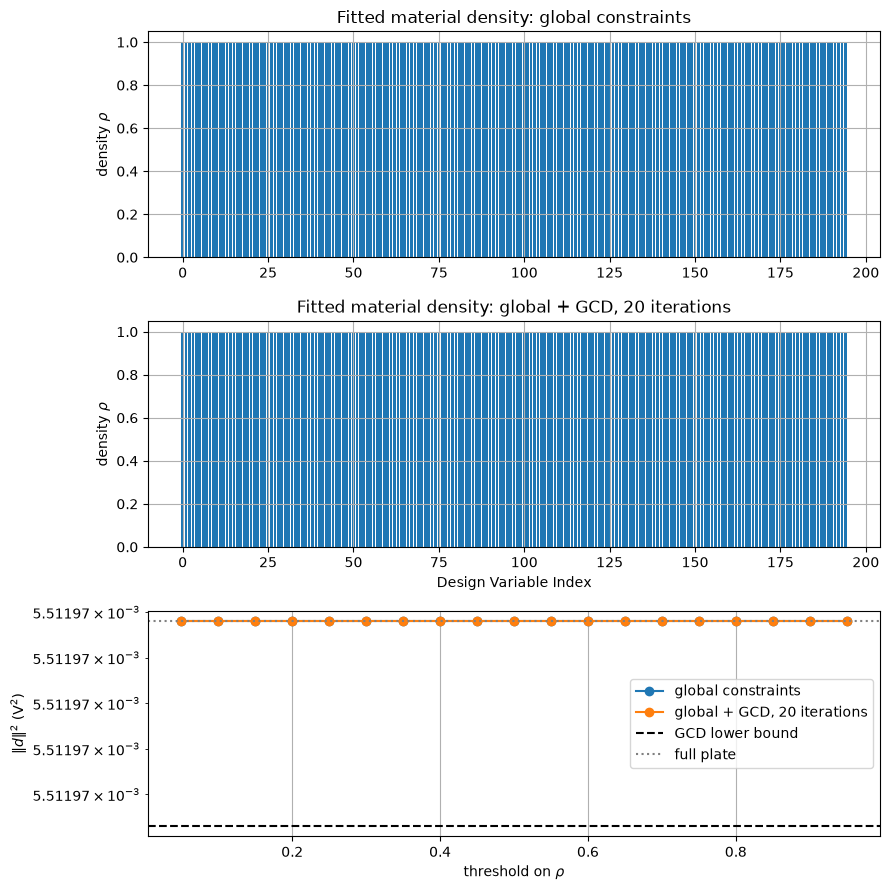

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9))
for ax, (name, (rho, _)) in zip(axes[:2], fits.items()):
    ax.bar(np.arange(Ndes), rho)
    ax.set_ylabel(r'density $\rho$'); ax.set_title(f'Fitted material density: {name}'); ax.grid(True)
axes[1].set_xlabel('Design Variable Index')
for name, (_, Pbin) in fits.items():
    axes[2].plot(ths, Pbin, 'o-', label=name)
axes[2].axhline(-gQCQP.current_dual, ls='--', c='k', label='GCD lower bound')
axes[2].axhline(Pfull, ls=':', c='gray', label='full plate')
axes[2].set_xlabel(r'threshold on $\rho$'); axes[2].set_ylabel(r'$\|d\|^2$ (V$^2$)'); axes[2].set_yscale('log'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()